# <center>MDSA D208 Predictive Modeling</center> 

## <center>Task 1</center>

## <center>Justin Jordan</center>

## <center>2/19/2025</center>

## <center>WGU</center>



## Part I: Research Question

### A.  Describe the purpose of this data analysis by doing the following:

1.  Summarize one research question that is relevant to a real-world organizational situation captured in the data set you have selected and that you will answer using multiple linear regression in the initial model.
    - Does the customers monthly charge predict a customers churn?  I believe this is an important question to an organization as it costs 10 times more to acquire a new customer than to retain an existing one(Churn Data Consideration and Dictionary 2024).

2.  Define the goals of the data analysis.
    - The goal of this analysis is to better understand the relationships, if any, between the MonthlyCharge variable and other variables that may be able to predict a customers churn.  The MonthlyCharge variable will be the dependent variable used in the models.  We will use multiple independent variables to see if there is a relevant relationship between the dependent variable and the independent variables in order to determine any predictive affects MonthlyCharge may have on a customers churn. 

## Part II: Method Justification

### B.  Describe multiple linear regression methods by doing the following:

1.  Summarize four assumptions of a multiple linear regression model.
    - Multiple linear regression(MLR) model is a statistical technique that uses multiple independent variables to predict the outcome of a dependent variable.  Four assumptions of MLR are:
        - Linearity - Assumption there is a linear relationship between dependent and independent variables
        - No Multicollinearity - Assumption that independent variables are not highly correlated with each other
        - Multivariate Normality - Assumption that the residuals are normally distributed
        - No autocorrelation - Assumption that there is little or no autocorrelation in the data.  This is also known as independence of independent variables.

2.  Describe two benefits of using Python or R in support of various phases of the analysis.
    - In this analysis, we will be using Python within a Jupyter notebook.  This gives us the ease and flexibility to have code and markdown cells in one easy to follow document.  The use of Python allows us to use multiple libraries for MLR that can handle, model and process data.  Python combined with Jupyter make it easy for not only implementing and reading code, but also creating the visual representations of the code all in one place making it easier to understand the data that is being worked with.  

3.  Explain why multiple linear regression is an appropriate technique to use for analyzing the research question summarized in part I.
    -  Since MonthlyCharge is a numeric variable, multiple linear regression will be used.  Multiple linear regression attempts to model a relationship between two or more variables by using an equation to find out which independent variable has the largest impact on the dependent variable.  MontlyCharge will be the dependent variable in this analysis and several independent variables will be used to see if any of the independent variables have an impact on the dependent variable in order to answer the research question from part I.  

## Part III: Data Preparation

### C.  Summarize the data preparation process for multiple linear regression analysis by doing the following:

1.  Describe your data cleaning goals and the steps used to clean the data to achieve the goals that align with your research question including your annotated code.
- The goal is to have a clean data set that can be used for regression testing mentioned in part B above.  The following will be the steps taken in order to clean the data. 
    - needed packages will be imported into Python
    - pd.read_csv will be used to load data frame
    - .info() will be used to profile data frame
    - inspect data frame for duplicate values
    - .isnull().sum will be used to identify possible missing values
    - if missing values exist, they will be treated with imputation
    - identify outliers
    - Below is the code and output for section C1

In [67]:
# code for c1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# code for data frame
churn = pd.read_csv("C:/users/jjord/Documents/WGU/D208/PA1/churn_clean.csv")

# Profile of Data Frame
churn.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [68]:
# Missing values using isnull
churn.isnull().sum()

CaseOrder                  0
Customer_id                0
Interaction                0
UID                        0
City                       0
State                      0
County                     0
Zip                        0
Lat                        0
Lng                        0
Population                 0
Area                       0
TimeZone                   0
Job                        0
Children                   0
Age                        0
Income                     0
Marital                    0
Gender                     0
Churn                      0
Outage_sec_perweek         0
Email                      0
Contacts                   0
Yearly_equip_failure       0
Techie                     0
Contract                   0
Port_modem                 0
Tablet                     0
InternetService         2129
Phone                      0
Multiple                   0
OnlineSecurity             0
OnlineBackup               0
DeviceProtection           0
TechSupport   

In [69]:
# look at unique values for InternetService
churn.InternetService.unique()

array(['Fiber Optic', 'DSL', nan], dtype=object)

In [70]:
# Impute nulls for InternetService
churn["InternetService"].fillna("No Internet Service", inplace=True)

In [71]:
# verify InternetService no longer has nulls
churn["InternetService"].isnull().sum()

0

Columns Zip, Lat, Lng currently are floats or ints. There are not quantitative so will change datatype to object. These values are not meant for any type of calculation. Since the rest of the data types for categorical are set to object, these will aslo.

In [72]:
obj_columns = ["Zip", "Lat", "Lng"]
churn[obj_columns] = churn[obj_columns].astype(object)

In [73]:
# rename item columns
churn.rename(
    columns={
        "Item1": "Timely_response",
        "Item2": "Timely_fixes",
        "Item3": "Timely_replacements",
        "Item4": "Reliability",
        "Item5": "Options",
        "Item6": "Respectful_response",
        "Item7": "Courteous_exchange",
        "Item8": "Active_listening",
    },
    inplace=True,
)

In [74]:
#profile df after clean
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  object 
 8   Lat                   10000 non-null  object 
 9   Lng                   10000 non-null  object 
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [75]:
# code for outliers.
churn.describe()

,CaseOrder,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year,Timely_response,Timely_fixes,Timely_replacements,Reliability,Options,Respectful_response,Courteous_exchange,Active_listening
count,10000.00000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,9756.562400,2.0877,53.078400,39806.926771,10.001848,12.016000,0.994200,0.398000,34.526188,172.624816,3392.341550,3.490800,3.505100,3.487000,3.497500,3.492900,3.497300,3.509500,3.495600
std,2886.89568,14432.698671,2.1472,20.698882,28199.916702,2.976019,3.025898,0.988466,0.635953,26.443063,42.943094,2185.294852,1.037797,1.034641,1.027977,1.025816,1.024819,1.033586,1.028502,1.028633
min,1.00000,0.000000,0.0000,18.000000,348.670000,0.099747,1.000000,0.000000,0.000000,1.000259,79.978860,155.506715,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,738.000000,0.0000,35.000000,19224.717500,8.018214,10.000000,0.000000,0.000000,7.917694,139.979239,1236.470827,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,5000.50000,2910.500000,1.0000,53.000000,33170.605000,10.018560,12.000000,1.000000,0.000000,35.430507,167.484700,3279.536903,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
75%,7500.25000,13168.000000,3.0000,71.000000,53246.170000,11.969485,14.000000,2.000000,1.000000,61.479795,200.734725,5586.141370,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,10000.00000,111850.000000,10.0000,89.000000,258900.700000,21.207230,23.000000,7.000000,6.000000,71.999280,290.160419,7158.981530,7.000000,7.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000


#### C2.
2.  Describe the dependent variable and all independent variables using summary statistics that are required to answer the research question, including a screenshot of the summary statistics output for each of these variables.
    - Below are the descriptive stats for the dependent variable and all independent variables being used.
        - Dependent Variable - MonthlyCharge
        - Independent Variables - Tenure, Income, Age, Outage_sec_perweek, Yearly_equip_failure, Bandwidth_GB_Year, InternetService, Phone, Gender

In [76]:
#c2 code descriptive stats for dependent variable MonthlyCharge
churn['MonthlyCharge'].describe()

count    10000.000000
mean       172.624816
std         42.943094
min         79.978860
25%        139.979239
50%        167.484700
75%        200.734725
max        290.160419
Name: MonthlyCharge, dtype: float64

Descriptive stats for independent Variables - Tenure, Income, Age, Outage_sec_perweek, Yearly_equip_failure, Bandwidth_GB_Year, InternetService, Phone, Gender

In [77]:
# descriptive stats for independent Variables 
churn['Tenure'].describe()


count    10000.000000
mean        34.526188
std         26.443063
min          1.000259
25%          7.917694
50%         35.430507
75%         61.479795
max         71.999280
Name: Tenure, dtype: float64

In [78]:
# descriptive stats for independent Variables
churn['Income'].describe()


count     10000.000000
mean      39806.926771
std       28199.916702
min         348.670000
25%       19224.717500
50%       33170.605000
75%       53246.170000
max      258900.700000
Name: Income, dtype: float64

In [79]:
# descriptive stats for independent Variables
churn['Age'].describe()


count    10000.000000
mean        53.078400
std         20.698882
min         18.000000
25%         35.000000
50%         53.000000
75%         71.000000
max         89.000000
Name: Age, dtype: float64

In [80]:
# descriptive stats for independent Variables
churn['Outage_sec_perweek'].describe()


count    10000.000000
mean        10.001848
std          2.976019
min          0.099747
25%          8.018214
50%         10.018560
75%         11.969485
max         21.207230
Name: Outage_sec_perweek, dtype: float64

In [81]:
# descriptive stats for independent Variables
churn['Yearly_equip_failure'].describe()


count    10000.000000
mean         0.398000
std          0.635953
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          6.000000
Name: Yearly_equip_failure, dtype: float64

In [82]:
# descriptive stats for independent Variables
churn['Bandwidth_GB_Year'].describe()


count    10000.000000
mean      3392.341550
std       2185.294852
min        155.506715
25%       1236.470827
50%       3279.536903
75%       5586.141370
max       7158.981530
Name: Bandwidth_GB_Year, dtype: float64

In [83]:
# descriptive stats for independent Variables
print(churn['InternetService'].describe())
print()
print(churn['InternetService'].value_counts())


count           10000
unique              3
top       Fiber Optic
freq             4408
Name: InternetService, dtype: object

InternetService
Fiber Optic            4408
DSL                    3463
No Internet Service    2129
Name: count, dtype: int64


In [84]:
# descriptive stats for independent Variables
print(churn['Phone'].describe())
print()
print(churn['Phone'].value_counts())



count     10000
unique        2
top         Yes
freq       9067
Name: Phone, dtype: object

Phone
Yes    9067
No      933
Name: count, dtype: int64


In [85]:
# descriptive stats for independent Variables
print(churn['Gender'].describe())
print()
print(churn['Gender'].value_counts())

count      10000
unique         3
top       Female
freq        5025
Name: Gender, dtype: object

Gender
Female       5025
Male         4744
Nonbinary     231
Name: count, dtype: int64


#### C3.
3.  Generate univariate and bivariate visualizations of the distributions of the dependent and independent variables, including the dependent variable in your bivariate visualizations.
    - Below is the code and output for the univariate and bivariate visualizations for the dependent and independent variables.


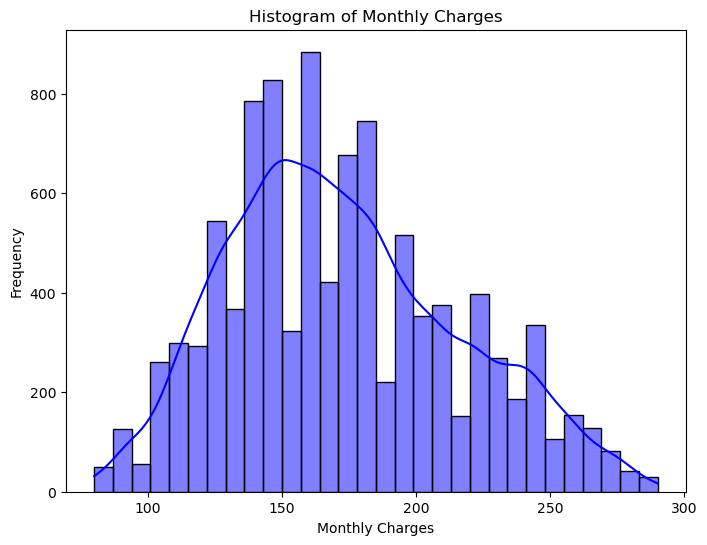

In [86]:
#c3 code visualizations for univariate
# MonthlyCharge Histogram

plt.figure(figsize=(8, 6))
sns.histplot(churn['MonthlyCharge'], kde=True, bins=30, color='blue')
plt.title('Histogram of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()

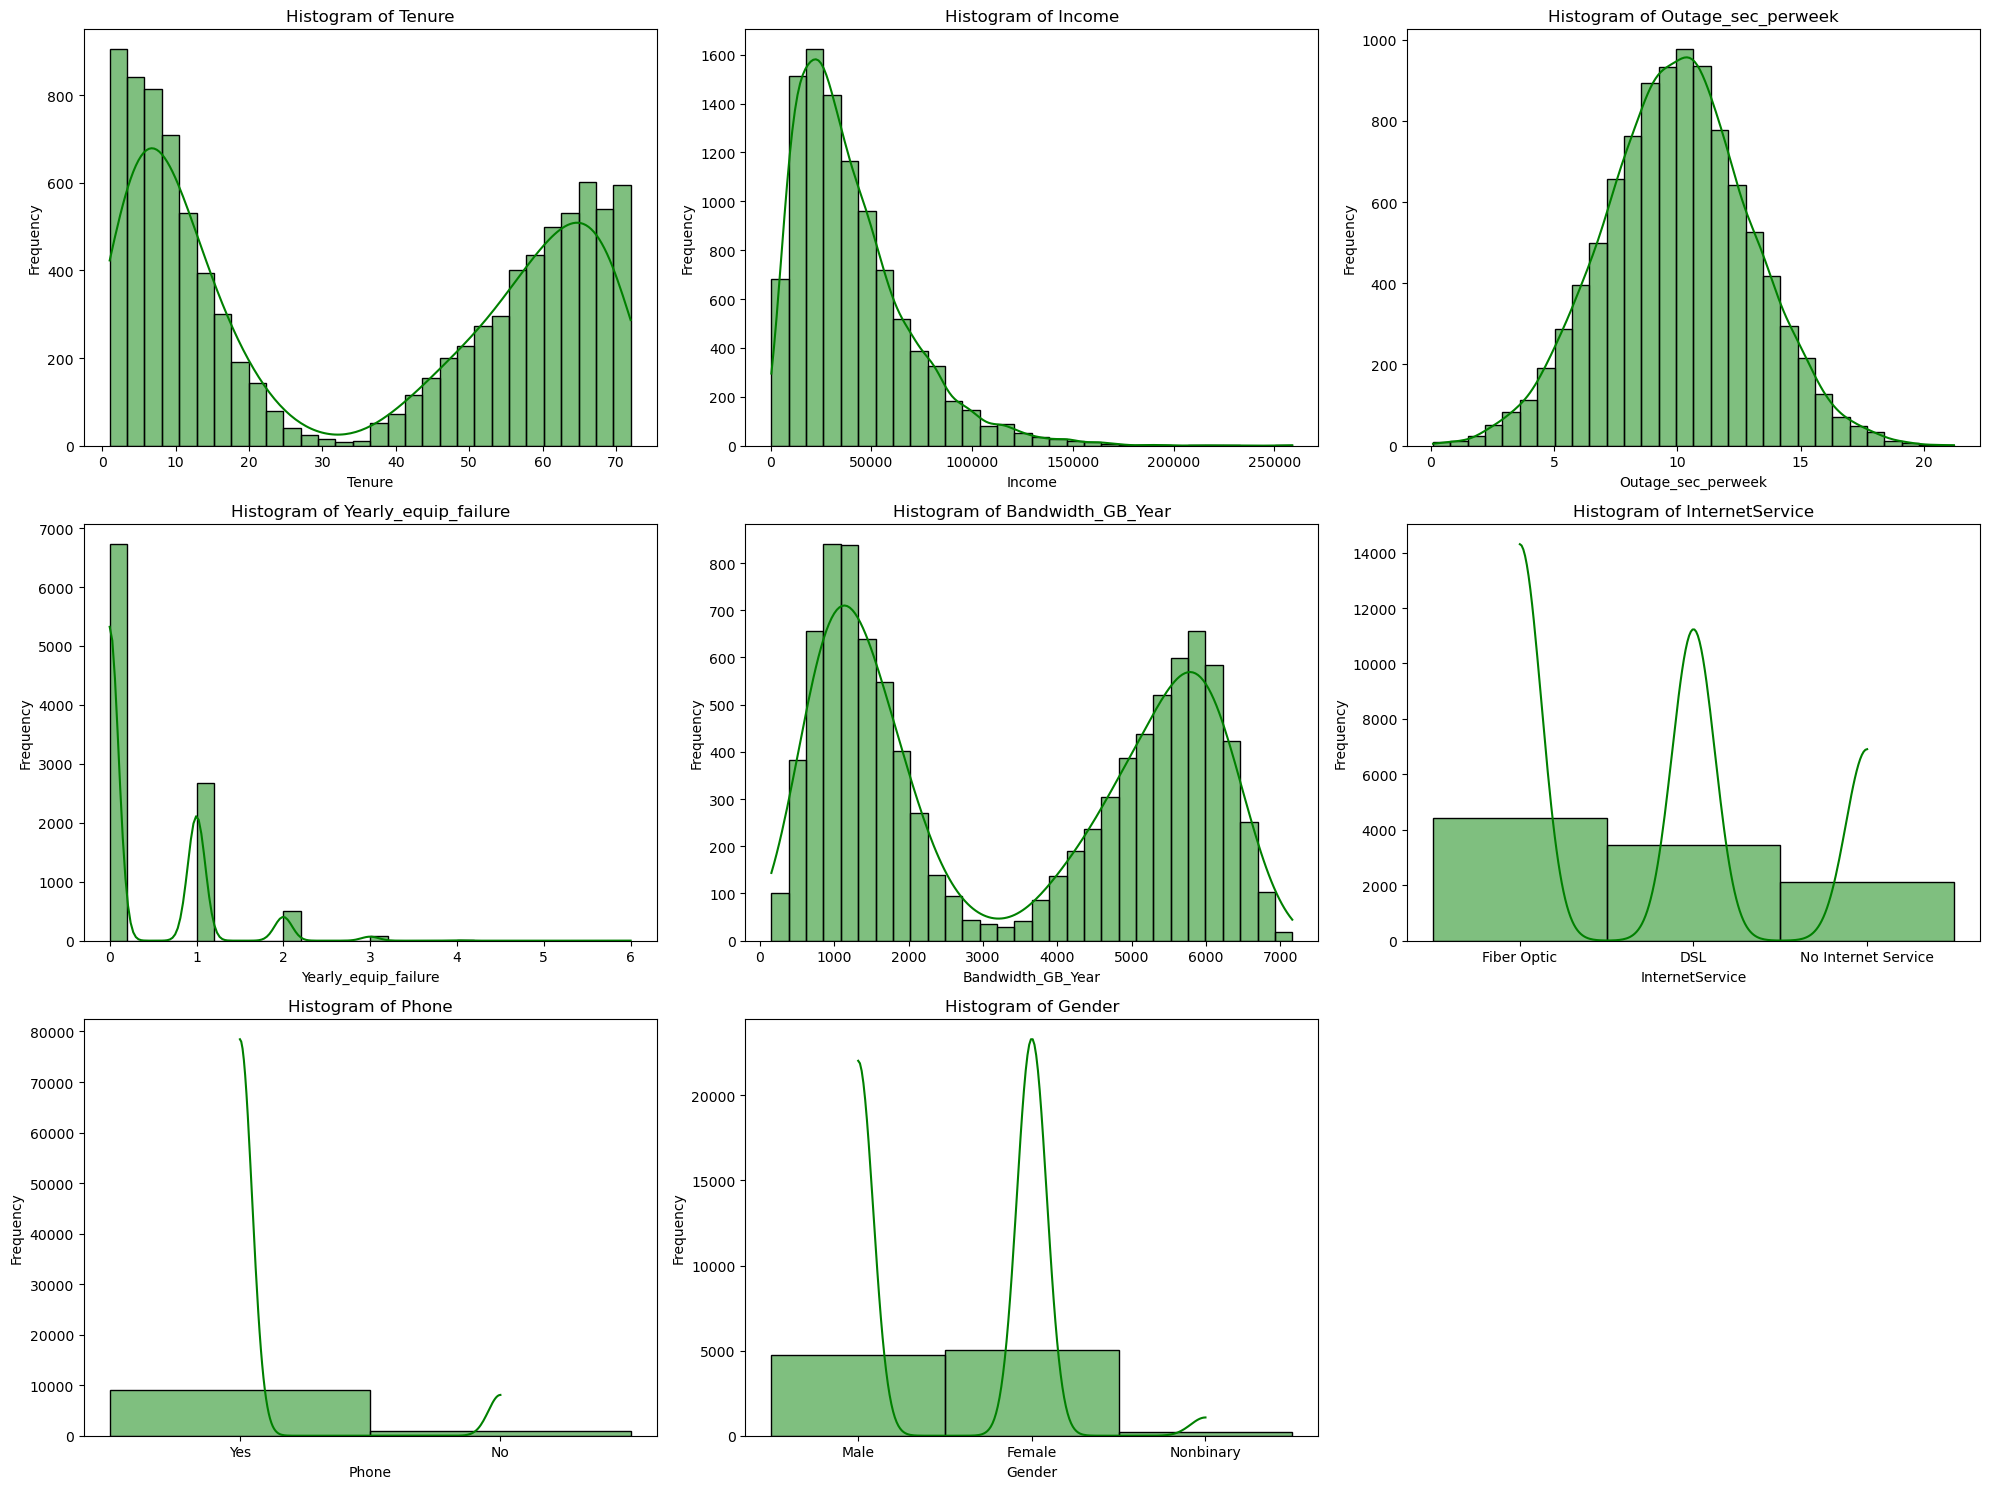

In [87]:
#c3 cont. code visualizations for univariate
#Independent variable histograms
plt.figure(figsize=(20, 15))
for x, col in enumerate(['Tenure', 'Income', 'Outage_sec_perweek', 'Yearly_equip_failure', 'Bandwidth_GB_Year', 'InternetService', 'Phone', 'Gender'], 1):
    plt.subplot(3, 3, x)
    sns.histplot(churn[col], kde=True, bins=30, color='green')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

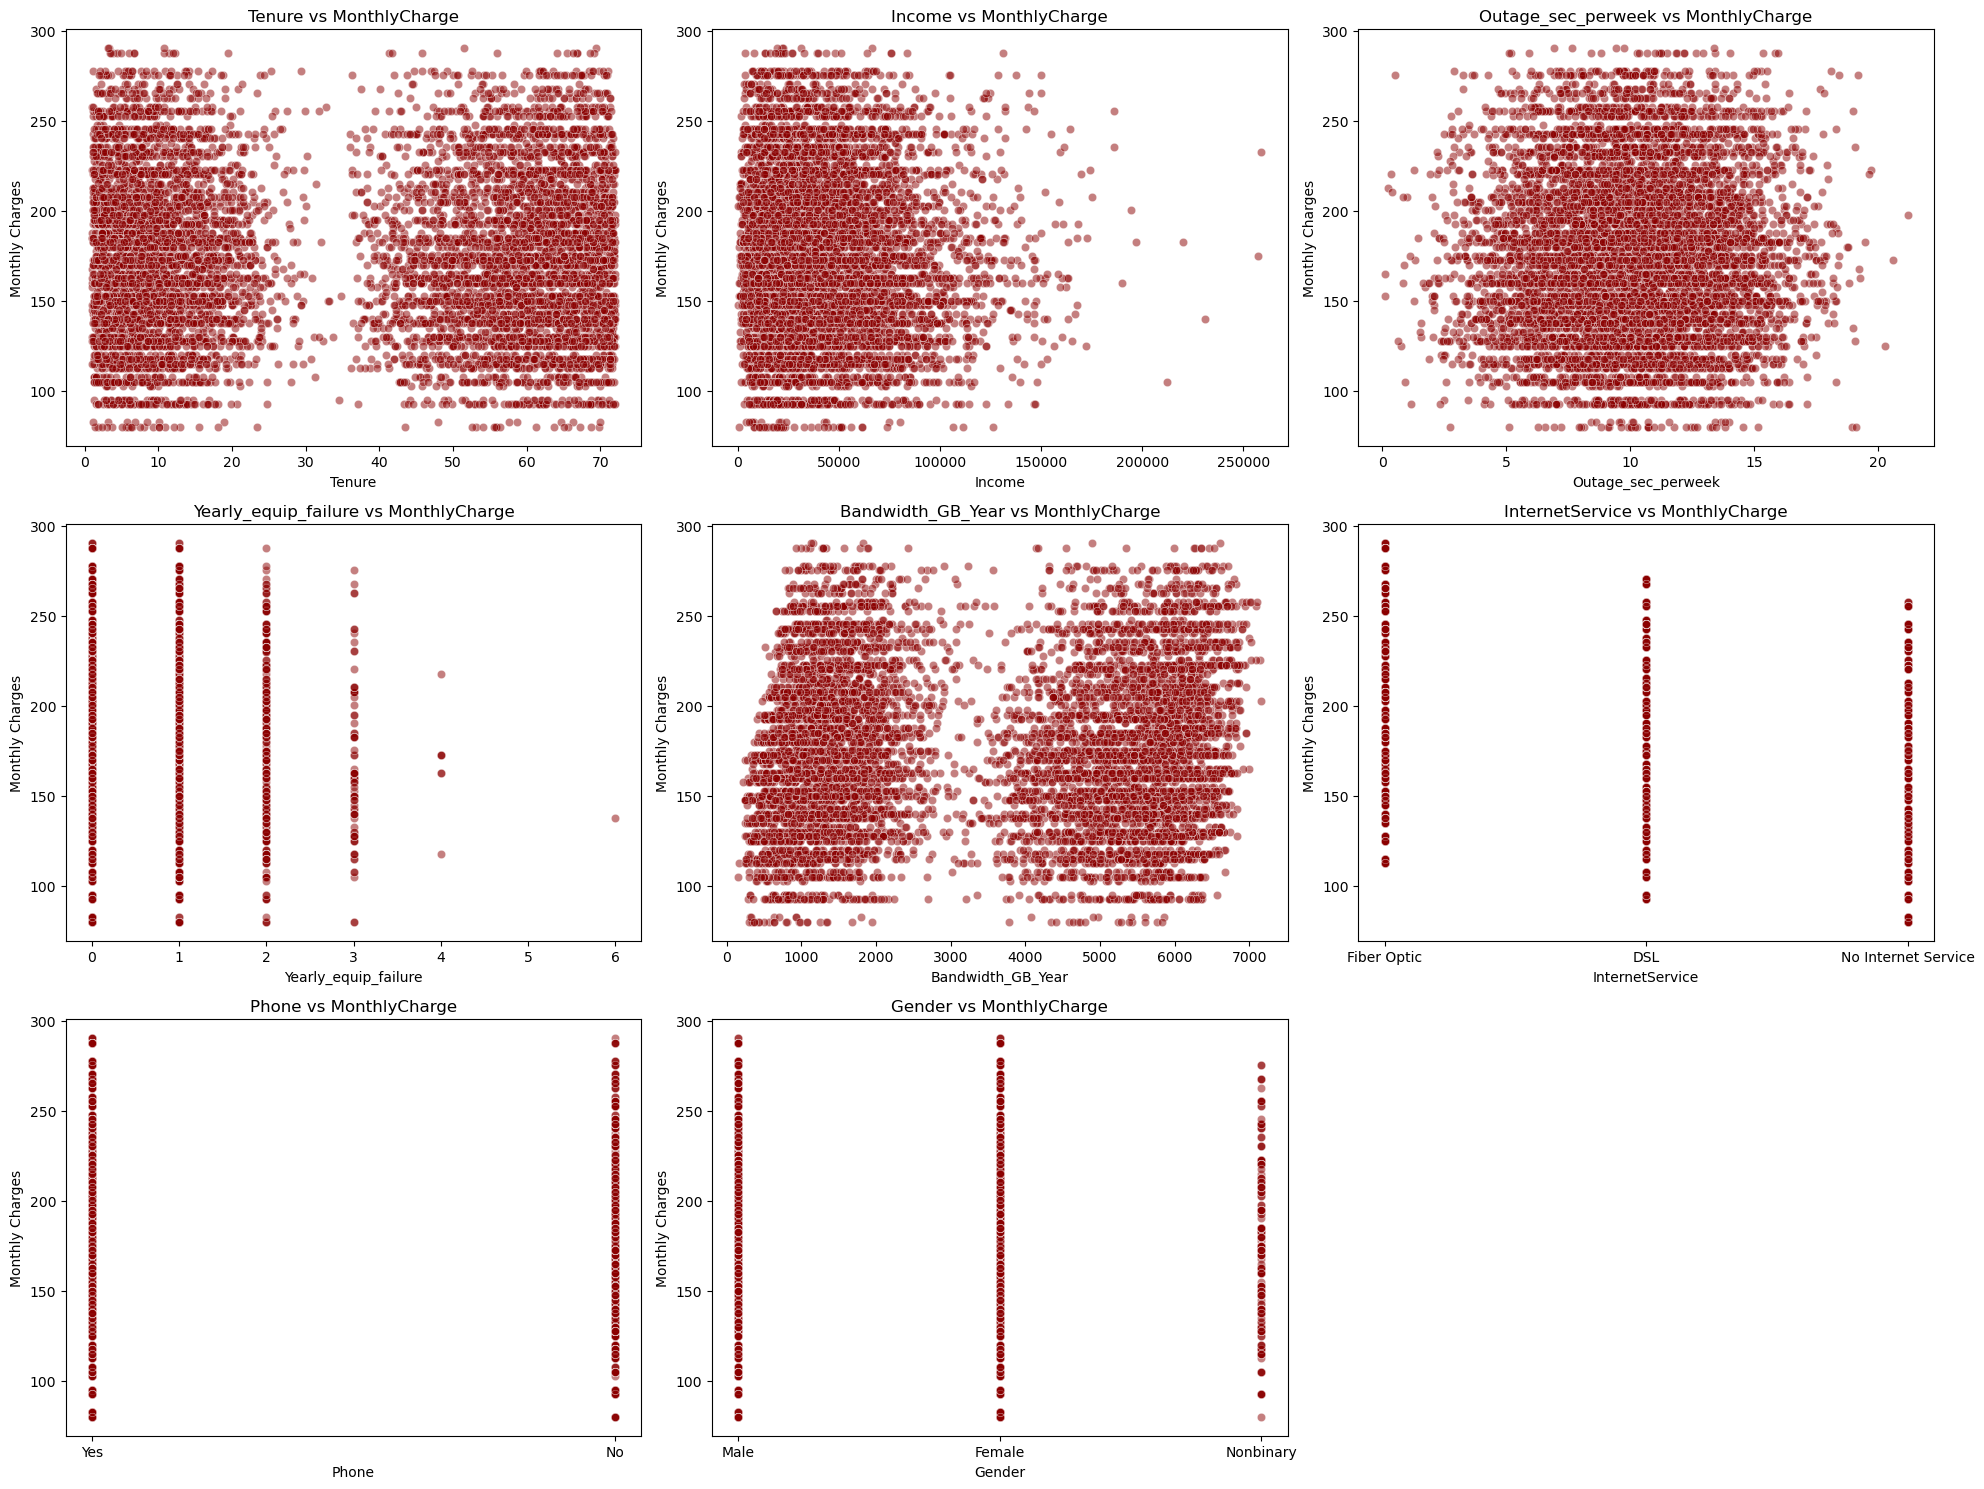

In [88]:
#code for bivariate visualizations for dependent variable(MonthlyCharge) against each independent variable(Tenure, Income, Age, Outage_sec_perweek, Yearly_equip_failure, Bandwidth_GB_Year, InternetService, Phone, Gender)

plt.figure(figsize=(20, 15))
for x, col in enumerate(['Tenure', 'Income', 'Outage_sec_perweek', 'Yearly_equip_failure', 'Bandwidth_GB_Year', 'InternetService', 'Phone', 'Gender'], 1):
    plt.subplot(3, 3, x)
    sns.scatterplot(data=churn, x=col, y='MonthlyCharge', color='darkred', alpha=0.5)
    plt.title(f'{col} vs MonthlyCharge')
    plt.xlabel(col)
    plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

#### 4.  Describe your data transformation goals that align with your research question and the steps used to transform the data to achieve the goals, including the annotated code.
    - The goals for data transformation will be to create new columns of the categorical variables that will be transformed into numeric variables.  The numeric variables are stored in new columns, preserving the originals.  Dummy variables will not need to be encoded since the model will use the transformed columns for the analysis.     

#### 5.  Provide the prepared data set as a CSV file.

Below is the code for both C4 & C5

In [89]:
#c4 & c5 code
#create new columns
churn['InternetService_num']=churn['InternetService']
churn['Phone_num']=churn['Phone']
churn['Gender_num']=churn['Gender']


In [90]:
#dictionary creation
dict_InternetService = {"Fiber Optic":0, "DSL":1, "No Internet Service":2}

dict_phone = {"No":0, "Yes":1}

dict_gender = {"Male":0, "Female":1, "Nonbinary":2}

In [91]:
#replace values from dictionaries above
churn['InternetService_num'].replace(dict_InternetService, inplace=True)
churn['Phone_num'].replace(dict_phone, inplace=True)
churn['Gender_num'].replace(dict_gender, inplace=True)

In [92]:
#verify new columns
churn.columns

Index(['CaseOrder', 'Customer_id', 'Interaction', 'UID', 'City', 'State',
       'County', 'Zip', 'Lat', 'Lng', 'Population', 'Area', 'TimeZone', 'Job',
       'Children', 'Age', 'Income', 'Marital', 'Gender', 'Churn',
       'Outage_sec_perweek', 'Email', 'Contacts', 'Yearly_equip_failure',
       'Techie', 'Contract', 'Port_modem', 'Tablet', 'InternetService',
       'Phone', 'Multiple', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'PaymentMethod', 'Tenure', 'MonthlyCharge',
       'Bandwidth_GB_Year', 'Timely_response', 'Timely_fixes',
       'Timely_replacements', 'Reliability', 'Options', 'Respectful_response',
       'Courteous_exchange', 'Active_listening', 'InternetService_num',
       'Phone_num', 'Gender_num'],
      dtype='object')

In [93]:
#c5 prepped data set
churn.to_csv('prep_churn.csv', index=False)

## Part IV: Model Comparison and Analysis

### D.  Compare an initial and a reduced linear regression model by doing the following:

1.  Construct an initial multiple linear regression model from all independent variables that were identified in part C2.



In [94]:
#d1 code
#create new dataframe for model
churn_model = churn[['MonthlyCharge', 'Tenure', 'Income', 'Age', 'Outage_sec_perweek','Yearly_equip_failure','Bandwidth_GB_Year','InternetService_num','Phone_num','Gender_num']].copy() 

churn_model

,MonthlyCharge,Tenure,Income,Age,Outage_sec_perweek,Yearly_equip_failure,Bandwidth_GB_Year,InternetService_num,Phone_num,Gender_num
0,172.455519,6.795513,28561.99,68,7.978323,1,904.536110,0,1,0
1,242.632554,1.156681,21704.77,27,11.699080,1,800.982766,0,1,1
2,159.947583,15.754144,9609.57,50,10.752800,1,2054.706961,1,1,1
3,119.956840,17.087227,18925.23,48,14.913540,0,2164.579412,1,1,0
4,149.948316,1.670972,40074.19,83,8.147417,1,271.493436,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,159.979400,68.197130,55723.74,23,9.415935,0,6511.252601,1,1,0
9996,207.481100,61.040370,34129.34,48,6.740547,0,5695.951810,0,1,0
9997,169.974100,47.416890,45983.43,48,6.590911,0,4159.305799,0,1,1
9998,252.624000,71.095600,16667.58,39,12.071910,0,6468.456752,0,0,0


In [95]:
#import statsmodel
import statsmodels.api as sm

In [96]:
# D1 initial model
#variables
x = churn_model[['Tenure', 'Income', 'Age', 'Outage_sec_perweek','Yearly_equip_failure','Bandwidth_GB_Year','InternetService_num','Phone_num','Gender_num']]
y = churn_model['MonthlyCharge']

#add constant to independent variables
x = sm.add_constant(x)

#fit multiple linear regression model
model = sm.OLS(y,x).fit()

#print model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.415
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     786.0
Date:                Tue, 04 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:16:11   Log-Likelihood:                -49111.
No. Observations:               10000   AIC:                         9.824e+04
Df Residuals:                    9990   BIC:                         9.831e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  118.2819 

#### D2
2.  Justify a statistically based feature selection procedure or a model evaluation metric to reduce the initial model in a way that aligns with the research question.
    - Backward elimination will be used to remove variables that are insignificant based on their p-values.  P-values with a significance level higher than .05 will be removed.  By doing this, it will remove variables that do not have a significant impact on the dependent variable.  

3.  Provide a reduced linear regression model that follows the feature selection or model evaluation process in part D2, including a screenshot of the output for each model.
    - Code for D3 is below

In [97]:
#code for d2 & d3
x = sm.add_constant(x)

#initial model
model = sm.OLS(y,x).fit()

#backward elimination
while True:
    p_values = model.pvalues[1:]  
    max_p_value = p_values.max()
    if max_p_value > 0.05:  
        max_p_index = p_values.idxmax()
        x = x.drop(columns=[max_p_index])
        model = sm.OLS(y, x).fit()
    else:
        break
#print model summary
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.414
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     1179.
Date:                Tue, 04 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:17:19   Log-Likelihood:                -49112.
No. Observations:               10000   AIC:                         9.824e+04
Df Residuals:                    9993   BIC:                         9.829e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 116.6806    

In [98]:
#code for d3
x = sm.add_constant(x)

#fit reduced model
reduced_model = sm.OLS(y,x[['const','Tenure','Age','Outage_sec_perweek','Bandwidth_GB_Year','InternetService_num','Gender_num']]).fit()

#print reduced model summary
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.414
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     1179.
Date:                Tue, 04 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:17:40   Log-Likelihood:                -49112.
No. Observations:               10000   AIC:                         9.824e+04
Df Residuals:                    9993   BIC:                         9.829e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 116.6806    

### E.  Analyze the data set using your reduced linear regression model by doing the following:

1.  Explain your data analysis process by comparing the initial multiple linear regression model and reduced linear regression model, including the following element:

•    Backward elimination was used to remove variables that are insignificant based on their p-values.  The model evaluation metric used was R squared.  In both models, the R squared valued was almost the same.  However, the F statistic value improved by a good amount after reducing the independent variables.  P-values with a significance level higher than .05 were removed.    
  

- Original Model R squared value = .415
- Reduced Model R squared value = .414

- Original Model F statistic value = 786
- Reduced Model F statistic value = 1179



#### E2
2.  Provide the output and all calculations of the analysis you performed, including the following elements for your reduced linear regression model:

•   a residual plot

•   the model’s residual standard error

3.  Provide an executable error-free copy of the code used to support the implementation of the linear regression models using a Python or R file.

- below is the code for E2 & E3

Summary of Residuals
Mean: 1.772641553543508e-11
Median: -0.8775084579627475
Standard Deviation: 32.8601171762473
Minimum: -92.6878695877903
Maximum: 96.24915924618924


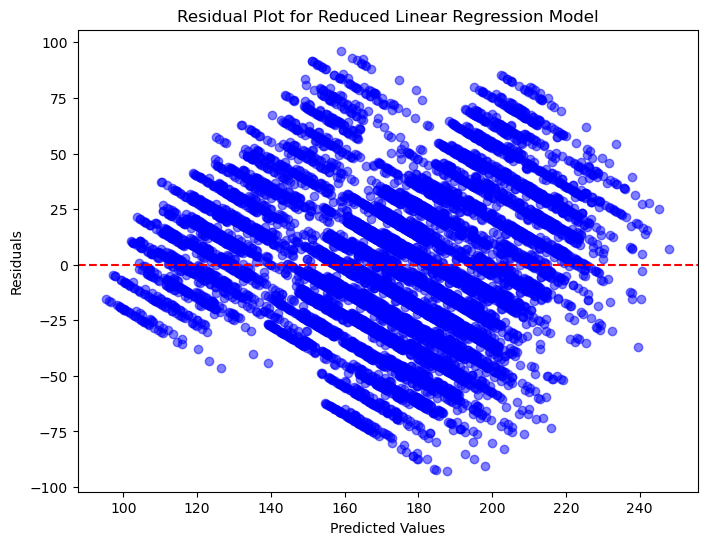

Residual Standard Error: 32.8601171762473


In [99]:
#code for e2 & e3
x = sm.add_constant(x)

#fit reduced model
reduced_model = sm.OLS(y,x[['const','Tenure','Age','Outage_sec_perweek','Bandwidth_GB_Year','InternetService_num','Gender_num']]).fit()

#residual and prediction calculations
predictions = reduced_model.predict()
residuals = reduced_model.resid

#summary stats calculation for residuals
residual_summary = {
    'Mean' : np.mean(residuals),
    'Median' : np.median(residuals),
    'Standard Deviation' : np.std(residuals),
    'Minimum' : np.min(residuals),
    'Maximum' : np.max(residuals)
}



#print summary stats
print("Summary of Residuals")
for stat, value in residual_summary.items():
    print(f"{stat}: {value}")

#plots for residuals
plt.figure(figsize=(8, 6))
plt.scatter(predictions, residuals, color='blue', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot for Reduced Linear Regression Model')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

#RSE
rse = np.sqrt(np.mean(residuals**2))

# Print the residual standard error
print(f"Residual Standard Error: {rse}")

## Part V: Data Summary and Implications

### F.  Summarize your findings and assumptions by doing the following:

1.  Discuss the results of your data analysis, including the following elements:

•   a regression equation for the reduced model
    - Y = 116.6806 + -7.3608(Tenure) + .3241(Age) + .2483(Outage_sec_perweek) + .0897(Bandwidth_BG_Year) + -21.8798(InternetService_num) + 5.5858(Gender_num)

•   an interpretation of the coefficients of the reduced model
    - Tenure decreased monthlycharge by 7.3608
    - Age increase montlycharge by .3241
    - Outage_sec_perweek increased monthlycharge by .2483
    - Bandwidth_GB_Year increased monthlycharge by .0897
    - InternetService_num decreased montlycharge by 21.8798
    - Gender_num increased montlycharge by 5.5858

  

•   the statistical and practical significance of the reduced model
- With the R squared value being .414, it suggests that model only explains 41.4% of the variance.  The lower R squared shows there is a variance in the dependent variable not explained by the independent variables used.  The statistical significance of the model is mediocre at best.

- There really isn't much of a practical significance of the reduced model. The relationship between the vairables suggest too low of a variance to be acceptable based upon the R squared value.


•   the limitations of the data analysis
-  There are several limitations with this analysis.  First, the standard error can be large.  Second, regression models are limited by correlation does not equal causation.  The model indicates varaibles that are most correlated with MonthlyCharge but it cannot be said that just because a customer uses more Bandwidth_GB_year that they pay more per month.  Lastly, with the R squared valued being low, it would also be considered a limitation.     

2.  Recommend a course of action based on your results.
- I would recommend that the data be furhter explored with different variables to see if a customers churn can be predicted by their monthly charge.  Based on the variables used, there is not enough variance here to accuratly predict churn.  After further analysis has been done, the company can then make an informed decision on the research question.  

## Part VI: Demonstration

### G.  Provide a Panopto video recording that includes the presenter and a vocalized demonstration of the functionality of the code used for the analysis of the programming environment, including the following elements:

•   an identification of the version of the programming environment

•   a comparison of the initial multiple linear regression model you used and the reduced linear regression model you used in your analysis

•   an interpretation of the coefficients of the reduced model

- https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=6df0b42d-bfcf-4c90-a60d-b297000224f3

### H.  List the web sources used to acquire data or segments of third-party code to support the application. Ensure the web sources are reliable.


### I.  Acknowledge sources, using in-text citations and references, for content that is quoted, paraphrased, or summarized.
    WGU. (n.d.). Churn Data Consideration and Dictionary. Data Files and Associated Dictionary Files. https://access.wgu.edu/ASP3/aap/content/d9rkejv84kd9rk30fi2l.zip 